In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Import Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset


In [ ]:
data_set = pd.read_csv("/content/drive/MyDrive/CSE422_project/medical_students_dataset - medical_students_dataset.csv")

In [ ]:
data_set

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,NaN,24.0,Male,176.503260,95.756997,B,30.737254,99.170685,65.0,121.0,130.0,No,No
199996,99997.0,29.0,Female,163.917675,45.225194,NaN,16.831734,97.865785,62.0,125.0,198.0,No,Yes
199997,99998.0,34.0,Female,NaN,99.648914,NaN,33.189303,98.768210,60.0,90.0,154.0,NaN,No
199998,99999.0,30.0,Female,156.446944,50.142824,A,20.486823,98.994212,61.0,106.0,225.0,No,No


In [ ]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Student ID      180000 non-null  float64
 1   Age             180000 non-null  float64
 2   Gender          180000 non-null  object 
 3   Height          180000 non-null  float64
 4   Weight          180000 non-null  float64
 5   Blood Type      180000 non-null  object 
 6   BMI             180000 non-null  float64
 7   Temperature     180000 non-null  float64
 8   Heart Rate      180000 non-null  float64
 9   Blood Pressure  180000 non-null  float64
 10  Cholesterol     180000 non-null  float64
 11  Diabetes        180000 non-null  object 
 12  Smoking         180000 non-null  object 
dtypes: float64(9), object(4)
memory usage: 19.8+ MB


In [ ]:
data_set['Diabetes'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
##Selecting numerical features
numerical_data = data_set.select_dtypes(include='number')
numerical_features=numerical_data.columns.tolist()
print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 9 numerical features: 

['Student ID', 'Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']


In [ ]:
#Selecting categoricalfeatures
categorical_data=data_set.select_dtypes(include= 'object')
categorical_features=categorical_data.columns.tolist()
print(f'There are {len(categorical_features)} numerical features:', '\n')
print(categorical_features)

There are 4 numerical features: 

['Gender', 'Blood Type', 'Diabetes', 'Smoking']


In [ ]:
print(f"Total data-point : {data_set.shape[0]}")

Total data-point : 200000


In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Student ID,180000.0,49974.042078,28879.641657,1.000000,24971.750000,49943.500000,74986.000000,100000.000000
Age,180000.0,26.021561,4.890528,18.000000,22.000000,26.000000,30.000000,34.000000
Height,180000.0,174.947103,14.447560,150.000041,162.476110,174.899914,187.464417,199.998639
Weight,180000.0,69.971585,17.322574,40.000578,54.969838,69.979384,84.980097,99.999907
BMI,180000.0,23.338869,7.033554,10.074837,17.858396,22.671401,27.997487,44.355113
Temperature,180000.0,98.600948,0.500530,96.397835,98.264750,98.599654,98.940543,100.824857
Heart Rate,180000.0,79.503767,11.540755,60.000000,70.000000,80.000000,90.000000,99.000000
Blood Pressure,180000.0,114.558033,14.403353,90.000000,102.000000,115.000000,127.000000,139.000000
Cholesterol,180000.0,184.486361,37.559678,120.000000,152.000000,184.000000,217.000000,249.000000


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Gender,180000,2,Male,90005
Blood Type,180000,4,B,45537
Diabetes,180000,2,No,161986
Smoking,180000,2,No,143971


In [ ]:
numerical_data.skew()

,0
Student ID,0.001083
Age,-0.003366
Height,0.002273
Weight,0.004820
BMI,0.438351
Temperature,0.010467
Heart Rate,-0.001063
Blood Pressure,-0.004830
Cholesterol,0.004155


# Histograms

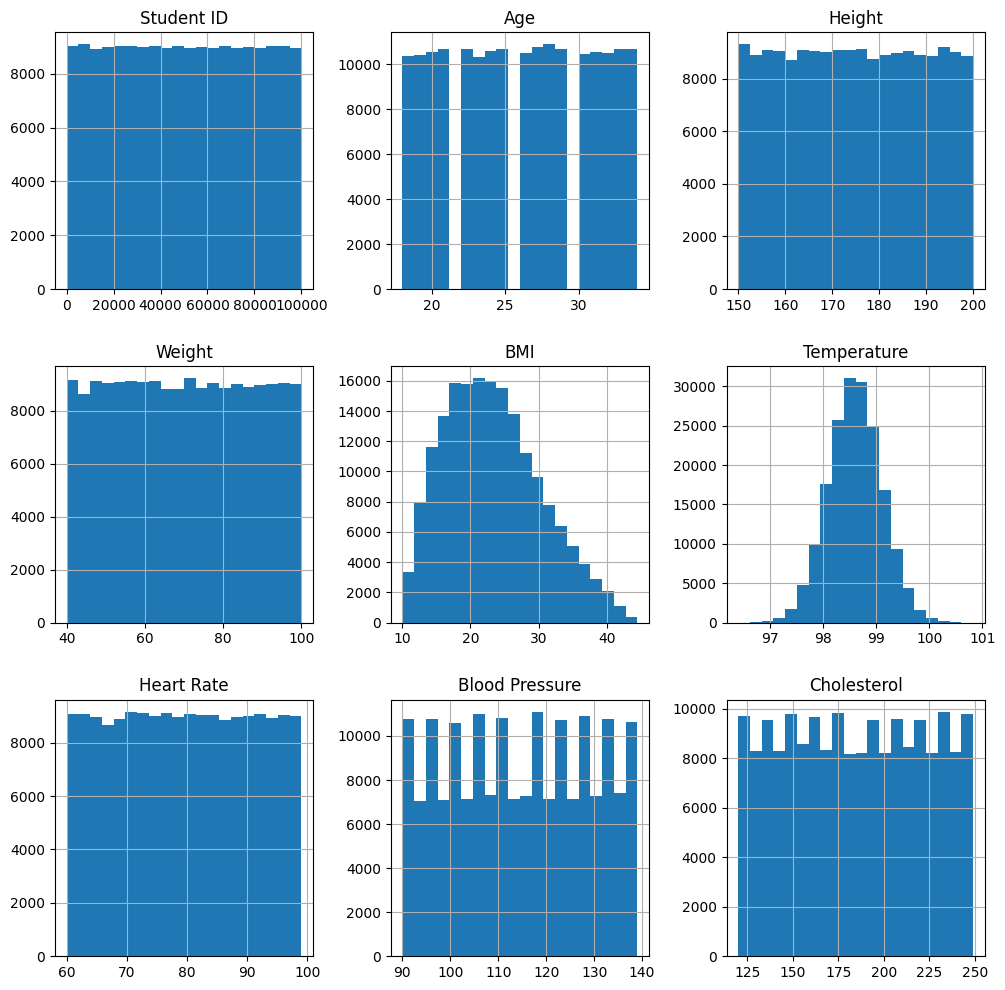

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

# Count Unique value in NumericDtype ans CategoricalDtype

In [ ]:
numerical_unique_count = numerical_data.nunique()
print(numerical_unique_count)

Student ID        98976
Age                  17
Height            98981
Weight            99025
BMI               98983
Temperature       98971
Heart Rate           40
Blood Pressure       50
Cholesterol         130
dtype: int64


In [ ]:
catagorical_unique_counts=categorical_data.nunique()
print(catagorical_unique_counts)

Gender        2
Blood Type    4
Diabetes      2
Smoking       2
dtype: int64


# Encoding


In [ ]:
data_set['Diabetes'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
# data_set = data_set.dropna(subset=["Diabetes"])

In [ ]:
data_set['Diabetes'] = data_set['Diabetes'].map({"Yes": 1, "No": 0})

In [ ]:
data_set

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,0.0,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,0.0,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,1.0,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,0.0,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,0.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,NaN,24.0,Male,176.503260,95.756997,B,30.737254,99.170685,65.0,121.0,130.0,0.0,No
199996,99997.0,29.0,Female,163.917675,45.225194,NaN,16.831734,97.865785,62.0,125.0,198.0,0.0,Yes
199997,99998.0,34.0,Female,NaN,99.648914,NaN,33.189303,98.768210,60.0,90.0,154.0,NaN,No
199998,99999.0,30.0,Female,156.446944,50.142824,A,20.486823,98.994212,61.0,106.0,225.0,0.0,No


In [ ]:
numerical_data = data_set.select_dtypes(include='number')
numerical_features=numerical_data.columns.tolist()
print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 10 numerical features: 

['Student ID', 'Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol', 'Diabetes']


In [ ]:
categorical_data=data_set.select_dtypes(include= 'object')
categorical_features=categorical_data.columns.tolist()
print(f'There are {len(categorical_features)} numerical features:', '\n')
print(categorical_features)

There are 3 numerical features: 

['Gender', 'Blood Type', 'Smoking']


# Correlation Analysis

Correlation Metrix


In [ ]:
correlation_matrix = numerical_data.corr()
correlation_matrix

,Student ID,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes
Student ID,1.000000,0.000349,0.003107,-0.001371,-0.003228,0.003705,0.003879,0.002076,-0.003341,-0.003203
Age,0.000349,1.000000,0.002026,0.004939,0.002984,0.003444,0.004778,-0.003577,-0.000946,0.003661
Height,0.003107,0.002026,1.000000,-0.000486,-0.551382,-0.003992,0.005855,0.003702,0.001831,-0.006663
Weight,-0.001371,0.004939,-0.000486,1.000000,0.821594,0.001355,-0.000069,0.002113,-0.001502,0.002688
BMI,-0.003228,0.002984,-0.551382,0.821594,1.000000,0.001356,-0.002198,-0.000215,-0.003336,0.002350
Temperature,0.003705,0.003444,-0.003992,0.001355,0.001356,1.000000,-0.004072,-0.003579,0.000159,-0.006482
Heart Rate,0.003879,0.004778,0.005855,-0.000069,-0.002198,-0.004072,1.000000,0.003121,0.004760,0.002452
Blood Pressure,0.002076,-0.003577,0.003702,0.002113,-0.000215,-0.003579,0.003121,1.000000,0.002858,-0.001388
Cholesterol,-0.003341,-0.000946,0.001831,-0.001502,-0.003336,0.000159,0.004760,0.002858,1.000000,0.002899
Diabetes,-0.003203,0.003661,-0.006663,0.002688,0.002350,-0.006482,0.002452,-0.001388,0.002899,1.000000


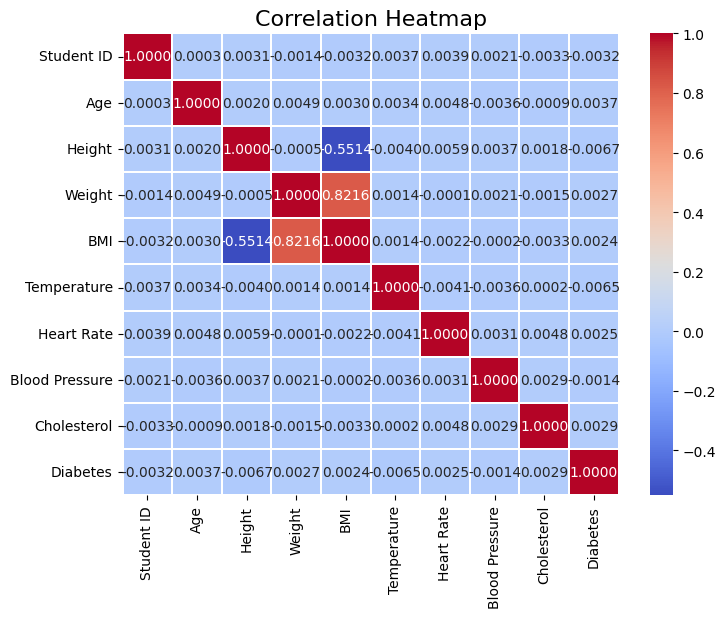

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.4f', linewidths=0.3)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

#### **Correlation plot between numerical features and target**
Here Target is **Cholesterol**

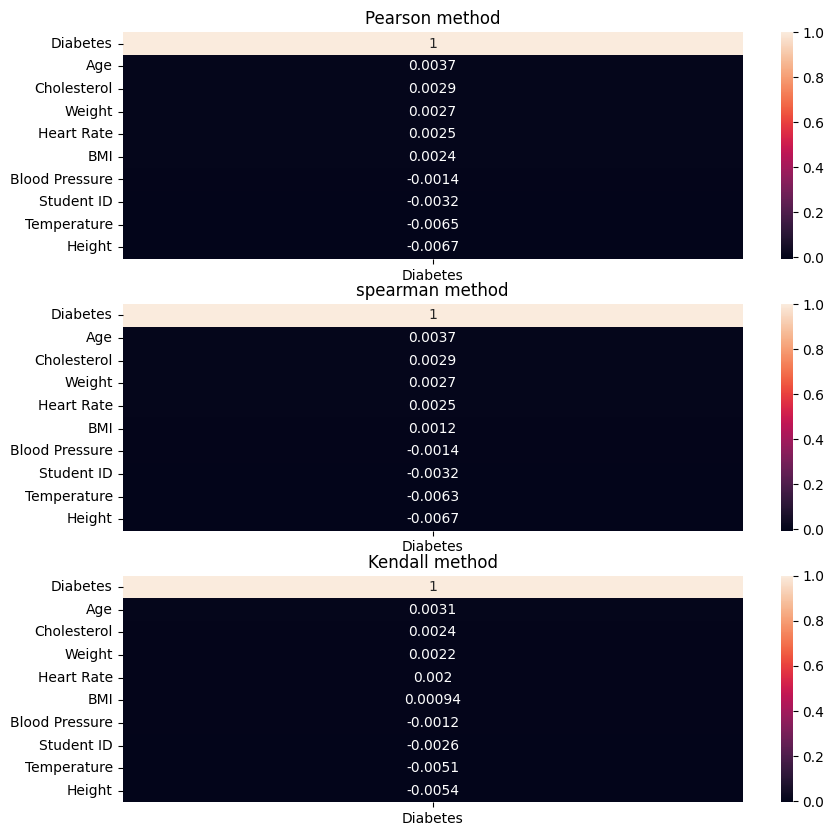

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(10, 10))
## Correlation coefficient using different methods
corr1 = numerical_data.corr('pearson')[['Diabetes']].sort_values(by='Diabetes', ascending=False)
corr2 = numerical_data.corr('spearman')[['Diabetes']].sort_values(by='Diabetes', ascending=False)
corr3 = numerical_data.corr('kendall')[['Diabetes']].sort_values(by='Diabetes', ascending=False)

#setting titles for each plot
ax[0].set_title('Pearson method')
ax[1].set_title('spearman method')
ax[2].set_title('Kendall method')

## Generating heatmaps of each methods
sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

 **Imbalance in the data**

In [ ]:
#check Imbalance in data

class_counts=data_set.groupby("Diabetes").size()
total_outputs = data_set.shape[0]
columns=['outcome','count','percentage']
outcome=[0,1]
count=list()
percentage=list()

for val in range(2):
    count.append(class_counts[val])
    percent=(class_counts[val]/total_outputs)*100
    percentage.append(percent)

# Convert the calulated values into a dataframe
imbalance_df=pd.DataFrame(list(zip(outcome,count,percentage)),columns=columns)
imbalance_df

,outcome,count,percentage
0,0,161986,80.993
1,1,18014,9.007


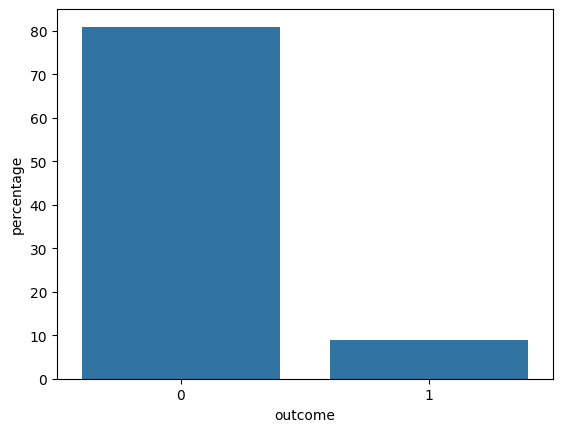

In [ ]:
sns.barplot(data=imbalance_df,x=imbalance_df['outcome'],y=imbalance_df['percentage'])
plt.show()

# **3.Dataset pre-processing**

1. **Faults**

  *   Null / Missing values
  *   Categorical values
  * Feature Scaling

2.   **Solutions**
  * Delete rows/columns
  * Impute values
  * Encoding(as required)
  * Scaling as per requirement


In [ ]:
# demonstrate 1st 10 value
data_set.head(10)

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,0.0,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,0.0,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,1.0,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,0.0,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,0.0,No
5,6.0,32.0,NaN,151.491294,68.647805,B,29.912403,99.668373,70.0,128.0,183.0,NaN,Yes
6,7.0,21.0,NaN,172.949704,48.102744,AB,16.081635,97.715469,66.0,134.0,247.0,0.0,No
7,8.0,28.0,Male,186.489402,52.389752,AB,15.063921,98.227788,85.0,123.0,128.0,0.0,No
8,9.0,21.0,Male,155.039678,42.958703,B,NaN,98.808053,NaN,111.0,243.0,0.0,No
9,10.0,32.0,NaN,170.836315,50.783250,B,17.400435,98.570168,61.0,94.0,166.0,NaN,No


In [ ]:
print(f"Total number of Row : {data_set.shape[0]}")
print(f"Total number of Column : {data_set.shape[1]}")

Total number of Row : 200000
Total number of Column : 13


In [ ]:
#counting the number of null values in the dataframe
data_set.isnull().sum()

,0
Student ID,20000
Age,20000
Gender,20000
Height,20000
Weight,20000
Blood Type,20000
BMI,20000
Temperature,20000
Heart Rate,20000
Blood Pressure,20000


In [ ]:
# Drop Temp ColumnS
data_set = data_set.drop(['BMI'],axis=1)
data_set.head(10)

,Student ID,Age,Gender,Height,Weight,Blood Type,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,NaN,95.0,109.0,203.0,0.0,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,98.714977,93.0,104.0,163.0,0.0,No
2,3.0,32.0,Female,182.537664,55.741083,A,98.260293,76.0,130.0,216.0,1.0,No
3,NaN,30.0,Male,182.112867,63.332207,B,98.839605,99.0,112.0,141.0,0.0,Yes
4,5.0,23.0,Female,NaN,46.234173,O,98.480008,95.0,NaN,231.0,0.0,No
5,6.0,32.0,NaN,151.491294,68.647805,B,99.668373,70.0,128.0,183.0,NaN,Yes
6,7.0,21.0,NaN,172.949704,48.102744,AB,97.715469,66.0,134.0,247.0,0.0,No
7,8.0,28.0,Male,186.489402,52.389752,AB,98.227788,85.0,123.0,128.0,0.0,No
8,9.0,21.0,Male,155.039678,42.958703,B,98.808053,NaN,111.0,243.0,0.0,No
9,10.0,32.0,NaN,170.836315,50.783250,B,98.570168,61.0,94.0,166.0,NaN,No


In [ ]:
print(f"Now , Total number of Column : {data_set.shape[1]}")

Now , Total number of Column : 12


Drop Row

In [ ]:
data_set = data_set.dropna(axis=0,subset=['Diabetes'])

In [ ]:
# data_set['Diabetes'] = data_set['Diabetes'].fillna(1)

Encoding

In [ ]:
data_set['Blood Type'] = data_set['Blood Type'].map({'A':1,'B':2,'C':3,'D':4})

In [ ]:
data_set['Smoking'] = data_set['Smoking'].map({'Yes':1,'No':0})

In [ ]:
data_set['Gender'] = data_set['Gender'].map({'Female':1,'Male':0})

In [ ]:
data_set.head(10)

,Student ID,Age,Gender,Height,Weight,Blood Type,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,1.0,161.777924,72.354947,NaN,NaN,95.0,109.0,203.0,0.0,NaN
1,2.0,NaN,0.0,152.069157,47.630941,2.0,98.714977,93.0,104.0,163.0,0.0,0.0
2,3.0,32.0,1.0,182.537664,55.741083,1.0,98.260293,76.0,130.0,216.0,1.0,0.0
3,NaN,30.0,0.0,182.112867,63.332207,2.0,98.839605,99.0,112.0,141.0,0.0,1.0
4,5.0,23.0,1.0,NaN,46.234173,NaN,98.480008,95.0,NaN,231.0,0.0,0.0
6,7.0,21.0,NaN,172.949704,48.102744,NaN,97.715469,66.0,134.0,247.0,0.0,0.0
7,8.0,28.0,0.0,186.489402,52.389752,NaN,98.227788,85.0,123.0,128.0,0.0,0.0
8,9.0,21.0,0.0,155.039678,42.958703,2.0,98.808053,NaN,111.0,243.0,0.0,0.0
10,11.0,28.0,1.0,152.973928,73.572814,2.0,98.371843,60.0,NaN,241.0,0.0,1.0
11,12.0,34.0,1.0,182.416302,76.371050,NaN,98.118274,86.0,97.0,247.0,0.0,0.0


**Without removing any value . Using sales by finding the average of the values and putting it into NaN**

In [ ]:
for lable in data_set.columns:
  if lable != 'Diabetes':
    impute = SimpleImputer(missing_values=np.nan, strategy='mean')
    impute.fit(data_set[[lable]])
    data_set[lable] = impute.transform(data_set[[lable]])

In [ ]:
data_set.head(10)

,Student ID,Age,Gender,Height,Weight,Blood Type,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.000000,18.000000,1.000000,161.777924,72.354947,1.505692,98.601001,95.000000,109.000000,203.0,0.0,0.199953
1,2.000000,26.027447,0.000000,152.069157,47.630941,2.000000,98.714977,93.000000,104.000000,163.0,0.0,0.000000
2,3.000000,32.000000,1.000000,182.537664,55.741083,1.000000,98.260293,76.000000,130.000000,216.0,1.0,0.000000
3,49966.577985,30.000000,0.000000,182.112867,63.332207,2.000000,98.839605,99.000000,112.000000,141.0,0.0,1.000000
4,5.000000,23.000000,1.000000,174.936197,46.234173,1.505692,98.480008,95.000000,114.556327,231.0,0.0,0.000000
6,7.000000,21.000000,0.499929,172.949704,48.102744,1.505692,97.715469,66.000000,134.000000,247.0,0.0,0.000000
7,8.000000,28.000000,0.000000,186.489402,52.389752,1.505692,98.227788,85.000000,123.000000,128.0,0.0,0.000000
8,9.000000,21.000000,0.000000,155.039678,42.958703,2.000000,98.808053,79.499438,111.000000,243.0,0.0,0.000000
10,11.000000,28.000000,1.000000,152.973928,73.572814,2.000000,98.371843,60.000000,114.556327,241.0,0.0,1.000000
11,12.000000,34.000000,1.000000,182.416302,76.371050,1.505692,98.118274,86.000000,97.000000,247.0,0.0,0.000000


In [ ]:
data_set_temp = data_set.drop(columns=['Diabetes'])
X_train, X_test, y_train, y_test = train_test_split(data_set_temp,data_set['Diabetes'],test_size=0.30,random_state=42,stratify=data_set['Diabetes'] )
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (126000, 11)
X_test shape: (54000, 11)
y_train shape: (126000,)
y_test shape: (54000,)


In [ ]:
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [ ]:
print("Per feature minimum before scaling")
print(X_train.min(axis=0))

Per feature minimum before scaling
Student ID          1.000000
Age                18.000000
Gender              0.000000
Height            150.000329
Weight             40.000718
Blood Type          1.000000
Temperature        96.397835
Heart Rate         60.000000
Blood Pressure     90.000000
Cholesterol       120.000000
Smoking             0.000000
dtype: float64


In [ ]:
print("Per feature maximum before scaling")
print(X_train.max(axis=0))

Per feature maximum before scaling
Student ID        100000.000000
Age                   34.000000
Gender                 1.000000
Height               199.998639
Weight                99.999460
Blood Type             2.000000
Temperature          100.824857
Heart Rate            99.000000
Blood Pressure       139.000000
Cholesterol          249.000000
Smoking                1.000000
dtype: float64


In [ ]:
print("Per feature minimum after scaling")
print(X_scaled_test.min(axis=0))

Per feature minimum after scaling
[-1.82818427 -1.73292503 -1.05512298 -1.81989163 -1.82573395 -1.50621222
 -4.63576637 -1.78036473 -1.79192498 -1.80728907 -0.52663695]


In [ ]:
print("Per feature minimum after scaling")
print(X_scaled_test.max(axis=0))

Per feature minimum after scaling
[1.8255801  1.7174522  1.05287757 1.82608194 1.82493396 1.47200057
 4.57158249 1.78306247 1.78697257 1.81359438 2.11157241]


In [ ]:
X_train

,Student ID,Age,Gender,Height,Weight,Blood Type,Temperature,Heart Rate,Blood Pressure,Cholesterol,Smoking
168991,68992.0,19.0,0.000000,174.936197,69.633160,1.505692,99.433821,79.499438,114.556327,187.0,0.0
90881,90882.0,30.0,0.000000,179.083981,54.150889,1.000000,97.814090,80.000000,132.000000,241.0,0.0
40754,40755.0,30.0,0.499929,160.523994,75.966436,2.000000,98.601001,74.000000,102.000000,244.0,1.0
170646,70647.0,22.0,1.000000,182.200121,69.994564,1.505692,98.895865,71.000000,121.000000,217.0,1.0
85986,85987.0,31.0,0.000000,151.392232,67.153106,1.505692,98.152112,69.000000,121.000000,179.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
89731,89732.0,31.0,0.499929,189.049409,52.549704,1.505692,99.075702,64.000000,118.000000,132.0,0.0
80150,80151.0,21.0,1.000000,175.439042,91.307497,1.000000,98.193422,79.499438,111.000000,155.0,0.0
106014,6015.0,20.0,0.000000,158.385507,69.994564,1.505692,99.371326,93.000000,112.000000,242.0,0.0
1901,1902.0,20.0,1.000000,184.651844,44.889789,1.505692,98.636900,86.000000,97.000000,208.0,0.0


In [ ]:
X_scaled_train
X_scaled_test

array([[-1.54019654e+00,  1.28615504e+00, -1.05512298e+00, ...,
         1.20266277e+00, -1.63887588e+00, -5.26636948e-01],
       [-2.99144932e-02,  2.07912159e-01, -1.05512298e+00, ...,
         1.27570149e+00, -1.02136088e+00, -5.26636948e-01],
       [-1.05067953e+00, -4.39033571e-01, -1.05512298e+00, ...,
         1.63788014e-03, -1.47046270e+00, -5.26636948e-01],
       ...,
       [ 1.31084909e+00, -7.73641747e-03,  1.05287757e+00, ...,
        -5.50266648e-01, -9.37154287e-01, -5.26636948e-01],
       [-1.37710947e+00, -1.81742513e-03, -1.05512298e+00, ...,
        -3.89955686e-02,  1.67325006e+00, -5.26636948e-01],
       [ 9.85625030e-01, -6.54682148e-01,  1.05287757e+00, ...,
        -9.15460276e-01, -1.55466929e+00, -5.26636948e-01]])

In [ ]:
y_train

,Diabetes
168991,0.0
90881,0.0
40754,0.0
170646,0.0
85986,0.0
...,...
89731,0.0
80150,0.0
106014,0.0
1901,0.0


# Train Model

# Logistic Regression

In [ ]:
logistic_regression_classifier = LogisticRegression(max_iter=5000)
logistic_regression_classifier.fit(X_scaled_train,y_train)
predicted_logistic = logistic_regression_classifier.predict(X_scaled_test)

Confusion matrix , precision_score , recall_score and f1_scorefor Logistic Regression

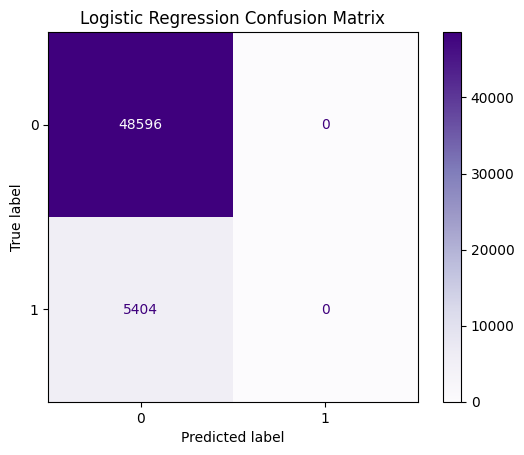

Logistic Regression model results:
Accuracy:  89.99%
Precision:  0.0%
Recall:  0.0%
F1 Score:  0.0%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
Confusion_metrix_logistic = confusion_matrix(y_test,predicted_logistic)
ConfusionMatrixDisplay(Confusion_metrix_logistic).plot(cmap="Purples")
plt.title("Logistic Regression Confusion Matrix")
plt.show()
print("Logistic Regression model results:")
print(f"Accuracy:  {round(accuracy_score(y_test, predicted_logistic)*100 , 2)}%")
print(f"Precision:  {round(precision_score(y_test, predicted_logistic)*100 , 2)}%")
print(f"Recall:  {round(recall_score(y_test, predicted_logistic)*100 , 2)}%")
print(f"F1 Score:  {round(f1_score(y_test, predicted_logistic)*100 , 2)}%")

# Decision Tree

In [ ]:
tree_classifier =  DecisionTreeClassifier()
tree_classifier.fit(X_scaled_train,y_train)
predicted_tree = tree_classifier.predict(X_scaled_test)

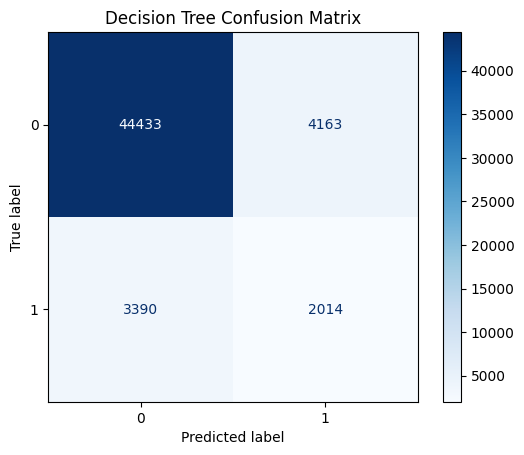

Decision tree model results:
Accuracy:  86.01%
Precision:  32.6%
Recall:  37.27%
F1 Score:  34.78%


In [ ]:
confusion_metrix_tree = confusion_matrix(y_test,predicted_tree)
ConfusionMatrixDisplay(confusion_metrix_tree).plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

print("Decision tree model results:")
print(f"Accuracy:  {round(accuracy_score(y_test, predicted_tree )*100 , 2)}%")
print(f"Precision:  {round(precision_score(y_test, predicted_tree )*100 , 2)}%")
print(f"Recall:  {round(recall_score(y_test, predicted_tree )*100 , 2)}%")
print(f"F1 Score:  {round(f1_score(y_test, predicted_tree )*100 , 2)}%")

# Neural network

In [ ]:
NN_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                         max_iter=300, random_state=42)
NN_model.fit(X_scaled_train, y_train)

MLPClassifier(max_iter=300, random_state=42)

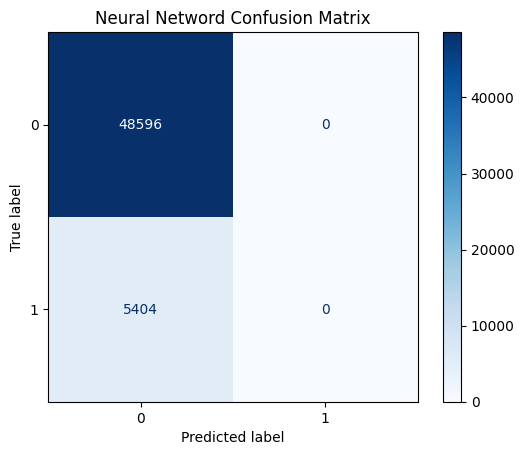

Neural Netword results
Accuracy:  89.99%
Precision:  0.0%
Recall:  0.0%
F1 Score:  0.0%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
predicted_NN = NN_model.predict(X_scaled_test)
consusion_NN = confusion_matrix(y_test,predicted_NN)
ConfusionMatrixDisplay(consusion_NN ).plot(cmap="Blues")
plt.title("Neural Netword Confusion Matrix")
plt.show()

print(f"Neural Netword results")
print(f"Accuracy:  {round(accuracy_score(y_test, predicted_NN )*100 , 2)}%")
print(f"Precision:  {round(precision_score(y_test, predicted_NN )*100 , 2)}%")
print(f"Recall:  {round(recall_score(y_test, predicted_NN )*100 , 2)}%")
print(f"F1 Score:  {round(f1_score(y_test, predicted_NN )*100 , 2)}%")

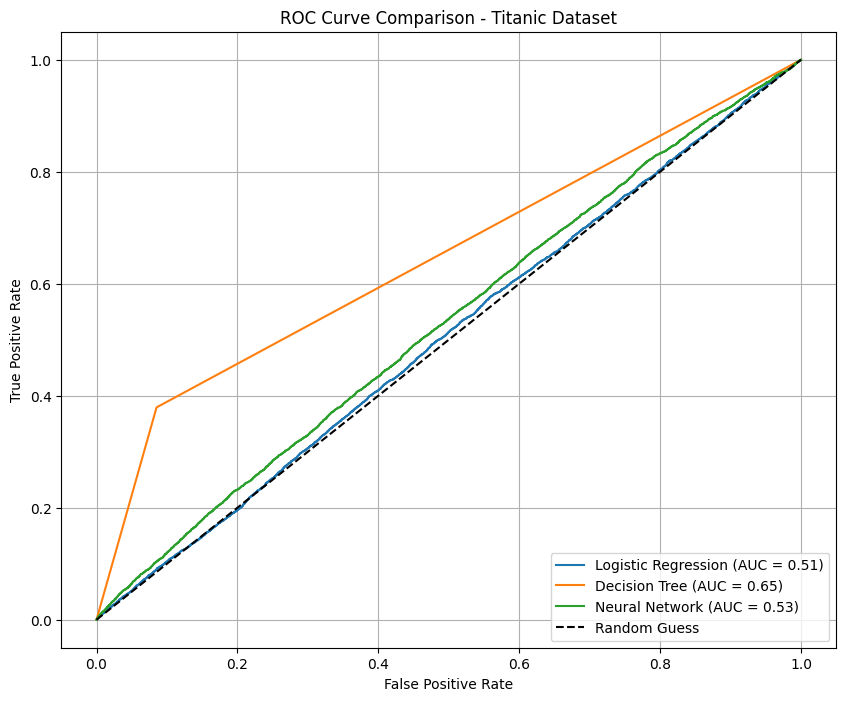

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Neural Network": MLPClassifier()

}


plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Fit
    model.fit(X_scaled_train, y_train)

    # Predict probabilities for class 1 (survived)
    y_probs = model.predict_proba(X_scaled_test)[:, 1]

    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Final plot setup
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Titanic Dataset")
plt.legend(loc="lower right")
plt.grid()
plt.show()


Text(0.5, 1.0, 'Prediction Accuracy of Classification Models')

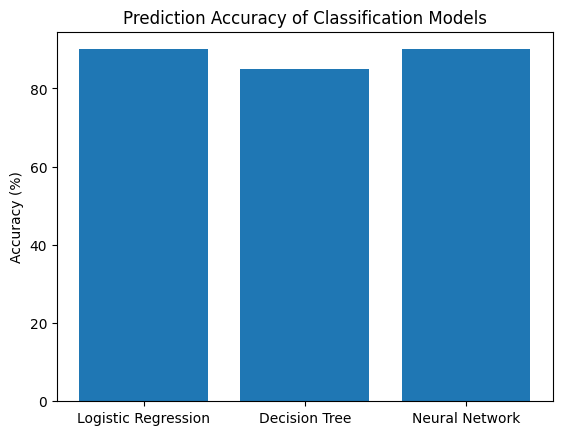

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Neural Network']
accuracies = [89.99,85.04,89.99]

bars = plt.bar(models, accuracies)
plt.ylabel('Accuracy (%)')
plt.title('Prediction Accuracy of Classification Models')

In [ ]:
print("Logistic Regression:")
print(classification_report(y_test,predicted_logistic))

print("Decision Tree")
print(classification_report(y_test, predicted_tree))

print("Neural Network")
print(classification_report(y_test, predicted_NN))

Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95     48596
         1.0       0.00      0.00      0.00      5404

    accuracy                           0.90     54000
   macro avg       0.45      0.50      0.47     54000
weighted avg       0.81      0.90      0.85     54000

Decision Tree
              precision    recall  f1-score   support

         0.0       0.93      0.91      0.92     48596
         1.0       0.33      0.37      0.35      5404

    accuracy                           0.86     54000
   macro avg       0.63      0.64      0.63     54000
weighted avg       0.87      0.86      0.86     54000

Neural Network
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95     48596
         1.0       0.00      0.00      0.00      5404

    accuracy                           0.90     54000
   macro avg       0.45      0.50      0.47     54000
weighted avg       0.81 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# K-means clustaring

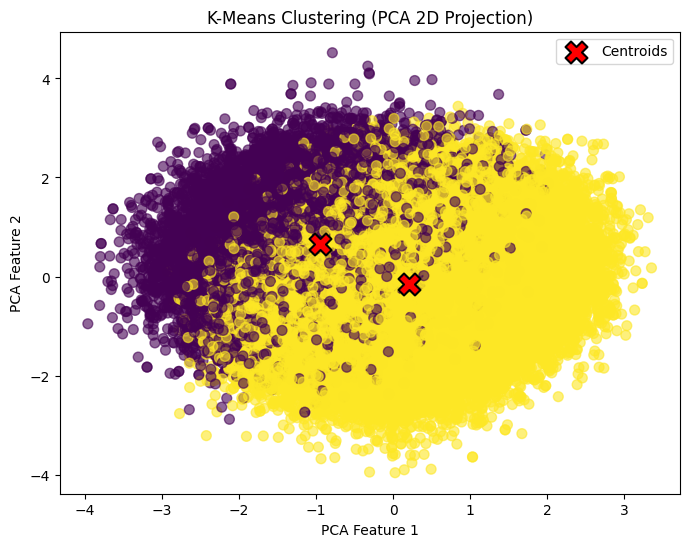

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled_train)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_train)

centers_pca = pca.transform(kmeans.cluster_centers_)


plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", s=50, alpha=0.6)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c="red", s=250, marker="X", edgecolor="k", linewidth=1.5, label="Centroids")
plt.title("K-Means Clustering (PCA 2D Projection)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.legend()
plt.show()